#Starter

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']
# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


# Helper Function

In [ ]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
epochs=20, batch_size=128, extra_callbacks=None):
  cb = extra_callbacks if extra_callbacks else []
  start = time.time()
  history = model.fit(x_tr, to_categorical(y_tr, 10),
                      validation_data=(x_v, to_categorical(y_v, 10)),
                      epochs=epochs, batch_size=batch_size,
                      callbacks=cb, verbose=0)
  elapsed = time.time() - start
  test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
  print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
  return history, test_acc, test_loss, elapsed

In [ ]:
def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
  plt.figure(figsize=(10, 6))
  for h, lbl in zip(histories, labels):
      plt.plot(h.history[metric], label=lbl)
  plt.xlabel('Epoch')
  plt.ylabel(ylabel if ylabel else metric)
  plt.title(title)
  plt.legend()
  plt.grid(True)
  plt.show()

#Task 1: Data Preprocessing Experiments

##1A. Normalization Comparison

BaselineCNN

In [ ]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## Input Preprocessing

In [ ]:
# Exp A: No normalization
x_train_A = x_train
x_val_A = x_val
x_test_A = x_test

# Exp B: Min-Max normalization
x_train_B = x_train / 255.0
x_val_B = x_val / 255.0
x_test_B = x_test / 255.0

# Exp C: Standardization
mean_C = np.mean(x_train, axis=(0, 1, 2))
std_C = np.std(x_train, axis=(0, 1, 2))

x_train_C = (x_train - mean_C) / (std_C )
x_val_C = (x_val - mean_C) / (std_C )
x_test_C = (x_test - mean_C) / (std_C )

Training

In [ ]:
EPOCHS = 20
BATCH_SIZE = 128

histories = []
test_accs = []
labels = []

print("Experiment A")
model_A = build_baseline_cnn()
h_A, t_acc_A, _, _ = train_and_evaluate(model_A, x_train_A, y_train, x_val_A, y_val, x_test_A, y_test, epochs=EPOCHS, batch_size=BATCH_SIZE)
histories.append(h_A)
test_accs.append(t_acc_A)

print("\nExperiment B")
model_B = build_baseline_cnn()
h_B, t_acc_B, _, _ = train_and_evaluate(model_B, x_train_B, y_train, x_val_B, y_val, x_test_B, y_test, epochs=EPOCHS, batch_size=BATCH_SIZE)
histories.append(h_B)
test_accs.append(t_acc_B)

print("\nExperiment C")
model_C = build_baseline_cnn()
h_C, t_acc_C, _, _ = train_and_evaluate(model_C, x_train_C, y_train, x_val_C, y_val, x_test_C, y_test, epochs=EPOCHS, batch_size=BATCH_SIZE)
histories.append(h_C)
test_accs.append(t_acc_C)

Experiment A


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.5366 | Test Loss: 2.9573 | Time: 50.0s

Experiment B
Test Acc: 0.6524 | Test Loss: 1.4618 | Time: 46.1s

Experiment C
Test Acc: 0.6529 | Test Loss: 2.1599 | Time: 49.7s


Graph

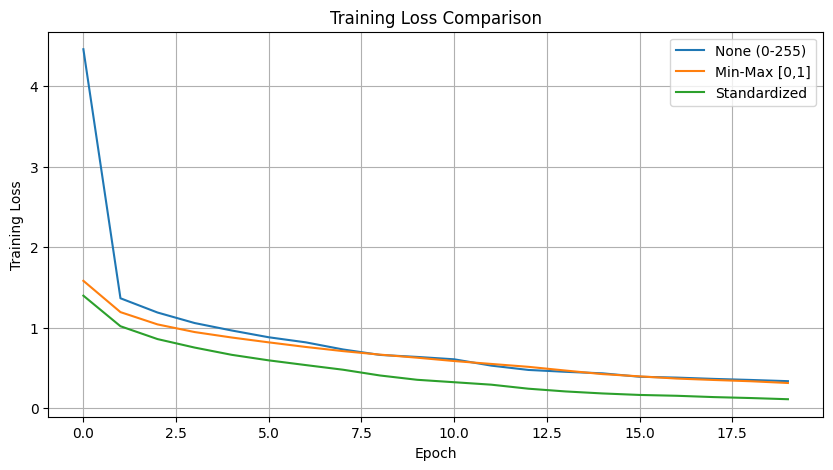

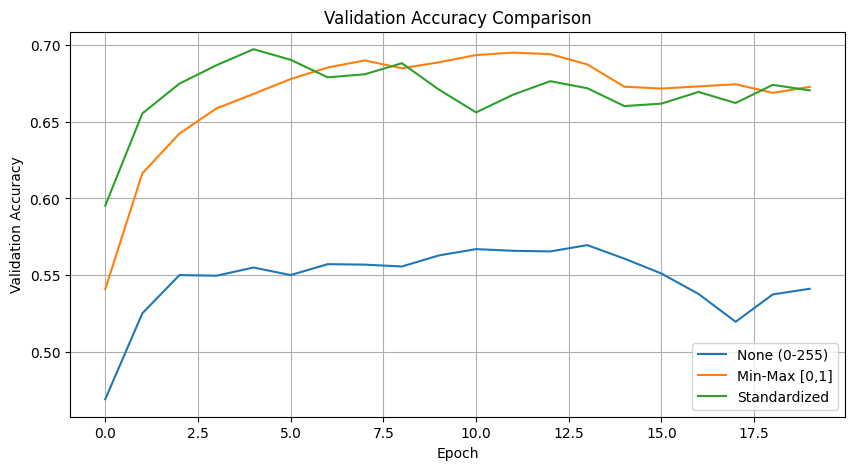

In [ ]:
labels = ['None (0-255)', 'Min-Max [0,1]', 'Standardized']


plt.figure(figsize=(10, 5))

for h, label in zip(histories[-3:], labels):
    plt.plot(h.history['loss'], label=label)

plt.title('Training Loss Comparison')
plt.ylabel('Training Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
for h, label in zip(histories[-3:], labels):
    plt.plot(h.history['val_accuracy'], label=label)

plt.title('Validation Accuracy Comparison')
plt.ylabel('Validation Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

Results Table Data

In [ ]:
print(f"{'Preprocessing':<18} | {'Train Acc':<10} | {'Val Acc':<10} | {'Test Acc':<10} | {'Loss @ Epoch 1':<14}")
print("-" * 75)

table_labels = ['None (0-255)', 'Min-Max [0,1]', 'Standardized']
for i, label in enumerate(table_labels):
    h = histories[i]
    train_acc = h.history['accuracy'][-1]
    val_acc = h.history['val_accuracy'][-1]
    test_acc = test_accs[i]
    loss_epoch_1 = h.history['loss'][0]

    print(f"{label:<18} | {train_acc:.4f}     | {val_acc:.4f}     | {test_acc:.4f}     | {loss_epoch_1:.4f}")

Preprocessing      | Train Acc  | Val Acc    | Test Acc   | Loss @ Epoch 1
---------------------------------------------------------------------------
None (0-255)       | 0.8857     | 0.5412     | 0.5366     | 4.4565
Min-Max [0,1]      | 0.8894     | 0.6726     | 0.6524     | 1.5822
Standardized       | 0.9605     | 0.6703     | 0.6529     | 1.3977


##1B. Data Augmentation Comparison

## No Augmentation

In [ ]:
print("WITHOUT Augmentation ")
model_no_aug = build_baseline_cnn()
h_no_aug, test_acc_no_aug, _, _ = train_and_evaluate(
    model_no_aug,
    x_train_C, y_train,
    x_val_C, y_val,
    x_test_C, y_test,
    epochs=40,
)

WITHOUT Augmentation 
Test Acc: 0.6769 | Test Loss: 3.2406 | Time: 84.5s


##With data augmentation

In [ ]:
EPOCHS_1B = 40
BATCH_SIZE_1B = 128
print("With Data Augmentation.")
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train_C)
model_aug = build_baseline_cnn()
start_time = time.time()
h_aug = model_aug.fit(
    datagen.flow(x_train_C, to_categorical(y_train, 10), batch_size=BATCH_SIZE_1B),
    validation_data=(x_val_C, to_categorical(y_val, 10)),
    epochs=EPOCHS_1B,
    verbose=0
)
elapsed_aug = time.time() - start_time
test_loss_aug, test_acc_aug = model_aug.evaluate(x_test_C, to_categorical(y_test, 10), verbose=0)
print(f"Test Acc (Augmented): {test_acc_aug:.4f} | Time: {elapsed_aug:.1f}s")

With Data Augmentation.
Test Acc (Augmented): 0.7641 | Time: 939.8s


## Single plot with 4 curves

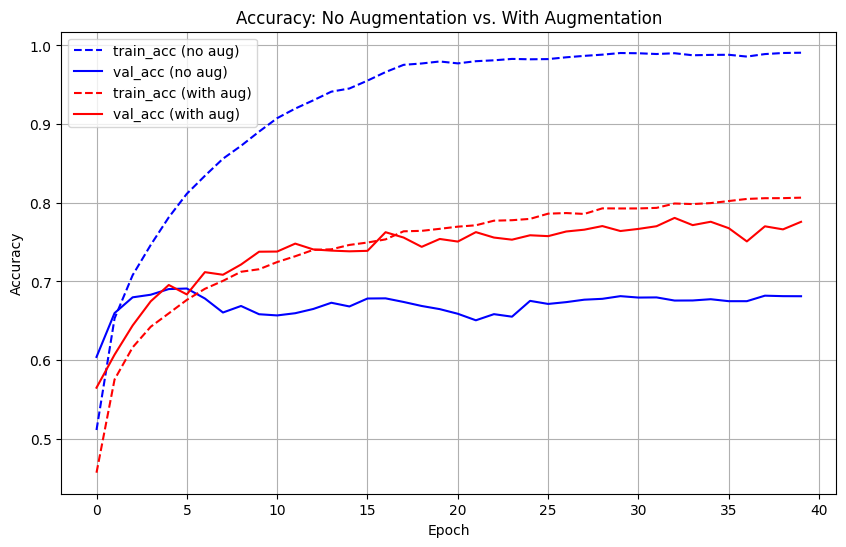

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(h_no_aug.history['accuracy'], label='train_acc (no aug)', linestyle='--', color='blue')
plt.plot(h_no_aug.history['val_accuracy'], label='val_acc (no aug)', linestyle='-', color='blue')

plt.plot(h_aug.history['accuracy'], label='train_acc (with aug)', linestyle='--', color='red')
plt.plot(h_aug.history['val_accuracy'], label='val_acc (with aug)', linestyle='-', color='red')

plt.title('Accuracy: No Augmentation vs. With Augmentation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Report

In [ ]:
# with out Augmentation
train_acc_no_aug = h_no_aug.history['accuracy'][-1]
val_acc_no_aug = h_no_aug.history['val_accuracy'][-1]
gap_no_aug = train_acc_no_aug - val_acc_no_aug

# Augmentation
train_acc_aug = h_aug.history['accuracy'][-1]
val_acc_aug = h_aug.history['val_accuracy'][-1]
gap_aug = train_acc_aug - val_acc_aug

print(f"Without Augmentation -> Train Acc: {train_acc_no_aug:.4f} | Val Acc: {val_acc_no_aug:.4f} | Gap: {gap_no_aug:.4f}")
print(f"With Augmentation    -> Train Acc: {train_acc_aug:.4f} | Val Acc: {val_acc_aug:.4f} | Gap: {gap_aug:.4f}\n")

if gap_aug < gap_no_aug:
    print("Conclusion: The model WITH Data Augmentation overfits LESS.")
    print("Explanation: The gap between training and validation accuracy is smaller, meaning better generalization.")
else:
    print("Conclusion: The model WITHOUT Data Augmentation overfits less.")

Without Augmentation -> Train Acc: 0.9908 | Val Acc: 0.6812 | Gap: 0.3096
With Augmentation    -> Train Acc: 0.8065 | Val Acc: 0.7758 | Gap: 0.0307

Conclusion: The model WITH Data Augmentation overfits LESS.
Explanation: The gap between training and validation accuracy is smaller, meaning better generalization.


#Task 2: CNN Architecture Experiments

## Task 2A: Filter Count Comparison

## Code for all 3 models

In [ ]:
def build_custom_cnn(f1, f2, f3, f4):
    model = models.Sequential([
        layers.Conv2D(f1, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(f2, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(f3, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(f4, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

EPOCHS_2A = 20
BATCH_SIZE_2A = 128
configs = {
    'Small': {'f1': 8, 'f2': 8, 'f3': 16, 'f4': 16},
    'Medium': {'f1': 32, 'f2': 32, 'f3': 64, 'f4': 64},
    'Large': {'f1': 64, 'f2': 64, 'f3': 128, 'f4': 128}
}
histories_2a = []
results_table = []
model_labels = []
for name, filters in configs.items():
    print(f"\nTraining Model: {name} {filters}")
    model = build_custom_cnn(filters['f1'], filters['f2'], filters['f3'], filters['f4'])



Training Model: Small {'f1': 8, 'f2': 8, 'f3': 16, 'f4': 16}

Training Model: Medium {'f1': 32, 'f2': 32, 'f3': 64, 'f4': 64}

Training Model: Large {'f1': 64, 'f2': 64, 'f3': 128, 'f4': 128}


## Model summary

In [ ]:
for name, filters in configs.items():
    print(f"\n{name} Model Summary")
    model = build_custom_cnn(filters['f1'], filters['f2'], filters['f3'], filters['f4'])

    model.summary()
    total_params = model.count_params()
    print(f"\nTraining {name} ")

    h, test_acc, test_loss, elapsed_time = train_and_evaluate(
        model,
        x_train_C, y_train,
        x_val_C, y_val,
        x_test_C, y_test,
        epochs=EPOCHS_2A,
        batch_size=BATCH_SIZE_2A
    )

    histories_2a.append(h)
    model_labels.append(name)

    train_acc = h.history['accuracy'][-1]
    val_acc = h.history['val_accuracy'][-1]

    results_table.append({
        'Model': name,
        'Total Params': total_params,
        'Train Acc': train_acc,
        'Val Acc': val_acc,
        'Test Acc': test_acc,
        'Time (s)': elapsed_time
    })

    print(f"Finished training {name}")


Small Model Summary


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,266 (1.03 MB)

 Trainable params: 269,266 (1.03 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,360,138 (9.00 MB)

 Trainable params: 2,360,138 (9.00 MB)

 Non-trainable params: 0 (0.00 B)


Training Large 
Test Acc: 0.7466 | Test Loss: 1.9421 | Time: 147.3s
Finished training Large


Fill in the results table

In [ ]:
print(f"{'Model':<10} | {'Total Params':<12} | {'Train Acc':<10} | {'Val Acc':<10} | {'Test Acc':<10} | {'Time (s)':<10}")
print("-" * 80)
for res in results_table:
    print(f"{res['Model']:<10} | {res['Total Params']:<12} | {res['Train Acc']:.4f}     | {res['Val Acc']:.4f}     | {res['Test Acc']:.4f}     | {res['Time (s)']:.1f}")

Model      | Total Params | Train Acc  | Val Acc    | Test Acc   | Time (s)  
--------------------------------------------------------------------------------
Small      | 269266       | 0.9198     | 0.6184     | 0.6148     | 43.7
Medium     | 1116970      | 0.9868     | 0.7197     | 0.7159     | 76.3
Large      | 2360138      | 0.9873     | 0.7474     | 0.7466     | 147.3


## Plot: val accuracy curves for all 3 models

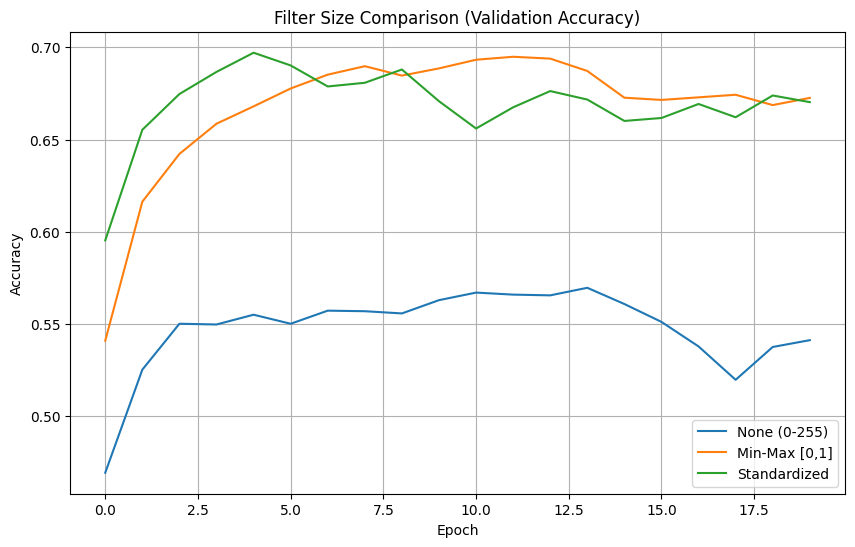

In [ ]:
plot_curves(
    histories,
    labels,
    metric='val_accuracy',
    title='Filter Size Comparison (Validation Accuracy)',
    ylabel='Accuracy'
)

##2C. Network Depth Comparison

Code for all 3 models

In [ ]:
def build_shallow():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_medium():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_deep():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## Train

In [ ]:
EPOCHS_2C = 20
BATCH_SIZE_2C = 128

models_dict = {
    'Shallow': build_shallow(),
    'Medium': build_medium(),
    'Deep': build_deep()
}

results_2c = []
histories_2c = {}

for name, model in models_dict.items():
    print(f"Training {name}")
    model.summary()
    total_params = model.count_params()

    h, test_acc, test_loss, elapsed_time = train_and_evaluate(
        model,
        x_train_C, y_train,
        x_val_C, y_val,
        x_test_C, y_test,
        epochs=EPOCHS_2C,
        batch_size=BATCH_SIZE_2C
    )

    histories_2c[name] = h
    train_acc = h.history['accuracy'][-1]
    val_acc = h.history['val_accuracy'][-1]

    results_2c.append({
        'Model': name,
        'Total Params': total_params,
        'Train Acc': train_acc,
        'Val Acc': val_acc,
        'Test Acc': test_acc,
        'Time (s)': elapsed_time
    })


Training Shallow


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,754 (2.12 MB)

 Trainable params: 555,754 (2.12 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,650 (299.41 KB)

 Trainable params: 76,650 (299.41 KB)

 Non-trainable params: 0 (0.00 B)

Test Acc: 0.7230 | Test Loss: 0.8962 | Time: 75.2s


Results table

In [ ]:
print(f"{'Model':<10} | {'Total Params':<12} | {'Train Acc':<10} | {'Val Acc':<10} | {'Test Acc':<10} | {'Time (s)':<10}")
print("-" * 80)
for res in results_2c:
    print(f"{res['Model']:<10} | {res['Total Params']:<12} | {res['Train Acc']:.4f}     | {res['Val Acc']:.4f}     | {res['Test Acc']:.4f}     | {res['Time (s)']:.1f}")

Model      | Total Params | Train Acc  | Val Acc    | Test Acc   | Time (s)  
--------------------------------------------------------------------------------
Shallow    | 555754       | 0.9809     | 0.6914     | 0.6900     | 68.0
Medium     | 58154        | 0.7975     | 0.7421     | 0.7345     | 71.1
Deep       | 76650        | 0.8314     | 0.7284     | 0.7230     | 75.2


## Plots

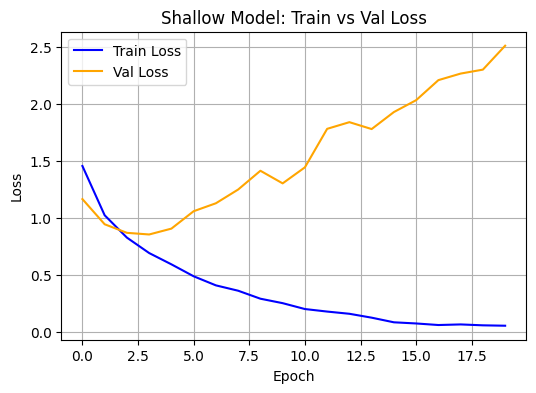

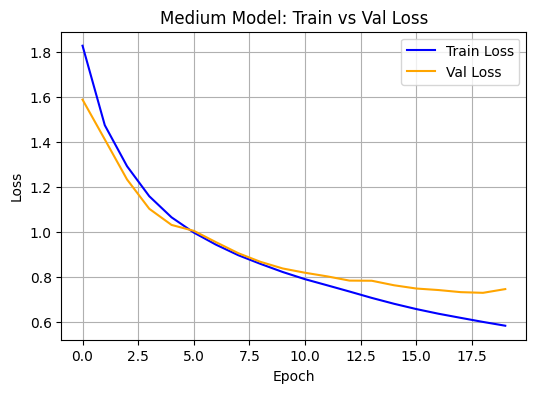

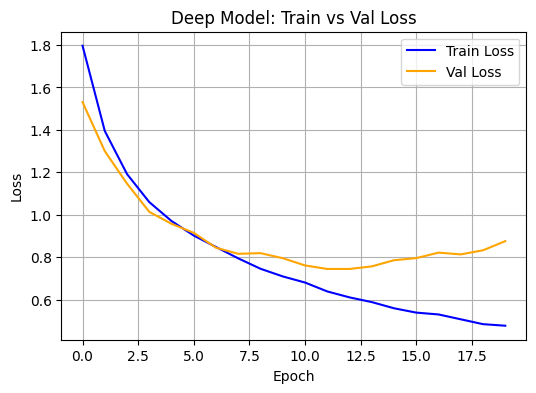

In [ ]:
for name, h in histories_2c.items():
    plt.figure(figsize=(6, 4))
    plt.plot(h.history['loss'], label='Train Loss', color='blue')
    plt.plot(h.history['val_loss'], label='Val Loss', color='orange')
    plt.title(f'{name} Model: Train vs Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

**Does the deepest model perform best? Why or why not?**

No, the deepest model does not perform best.

because its higher complexity isn’t matched by the data or tuning.

It tends to overfit or learn noise

The dataset is not large/complex enough to benefit from extra depth

the gap shows it’s still overfitting a bit,its extra complexity fits training data better than unseen data, which is why it doesn’t perform best.




#Task 3: Regularization Experiments

##3A. Dropout Rate Comparison

## Code for all 3 models

In [ ]:
def build_dropout_model(dropout_rate):
    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    # Flatten & Dense
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))  # Before output Dense
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

EPOCHS_3A = 30
BATCH_SIZE_3A = 128

configs_3a = {
    'D0': 0.0,
    'D1': 0.25,
    'D2': 0.5
}

results_3a = []
histories_3a = {}

print("Dropout Comparison\n")

for name, rate in configs_3a.items():
    print(f"Training Model {name} (Dropout Rate: {rate})")
    model = build_dropout_model(rate)

    h, test_acc, test_loss, _ = train_and_evaluate(
        model,
        x_train_C, y_train,
        x_val_C, y_val,
        x_test_C, y_test,
        epochs=EPOCHS_3A,
        batch_size=BATCH_SIZE_3A
    )

    histories_3a[name] = h
    train_acc_final = h.history['accuracy'][-1]
    val_acc_final = h.history['val_accuracy'][-1]
    overfit_gap = train_acc_final - val_acc_final

    results_3a.append({
      'Model': name,
      'Train Acc': train_acc_final,
      'Val Acc': val_acc_final,
      'Test Acc': test_acc,
      'Overfit Gap': overfit_gap
    })

Dropout Comparison

Training Model D0 (Dropout Rate: 0.0)
Test Acc: 0.7142 | Test Loss: 2.5717 | Time: 112.1s
Training Model D1 (Dropout Rate: 0.25)
Test Acc: 0.7701 | Test Loss: 0.9183 | Time: 120.7s
Training Model D2 (Dropout Rate: 0.5)
Test Acc: 0.7902 | Test Loss: 0.6108 | Time: 119.0s


## Results table

In [ ]:
print(f"{'Model':<8} | {'Train Acc':<10} | {'Val Acc':<10} | {'Test Acc':<10} | {'Overfit Gap':<12}")
print("-" * 65)
for res in results_3a:
    print(f"{res['Model']:<8} | {res['Train Acc']:.4f}    | {res['Val Acc']:.4f}    | {res['Test Acc']:.4f}    | {res['Overfit Gap']:.4f}")

Model    | Train Acc  | Val Acc    | Test Acc   | Overfit Gap 
-----------------------------------------------------------------
D0       | 0.9872    | 0.7166    | 0.7142    | 0.2706
D1       | 0.9280    | 0.7823    | 0.7701    | 0.1457
D2       | 0.7889    | 0.7952    | 0.7902    | -0.0063


## Plot: all 3 val accuracy curves

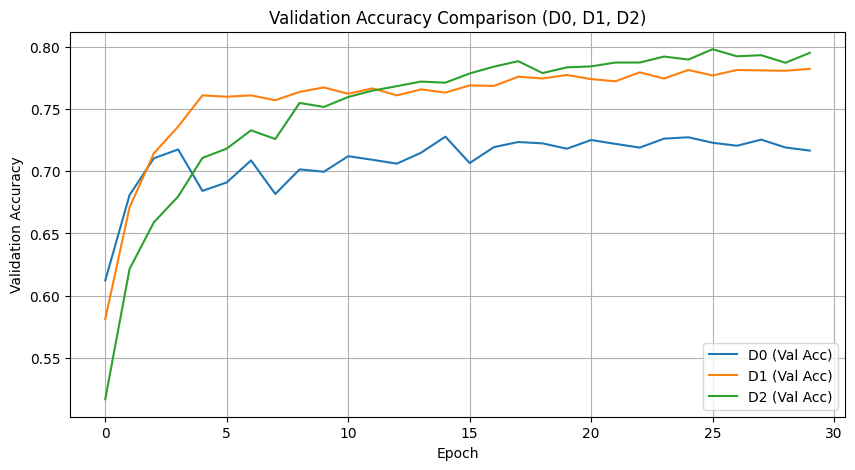

In [ ]:
plt.figure(figsize=(10, 5))
for name, h in histories_3a.items():
    plt.plot(h.history['val_accuracy'], label=f'{name} (Val Acc)')
plt.title('Validation Accuracy Comparison (D0, D1, D2)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Plot: all 3 train accuracy curves

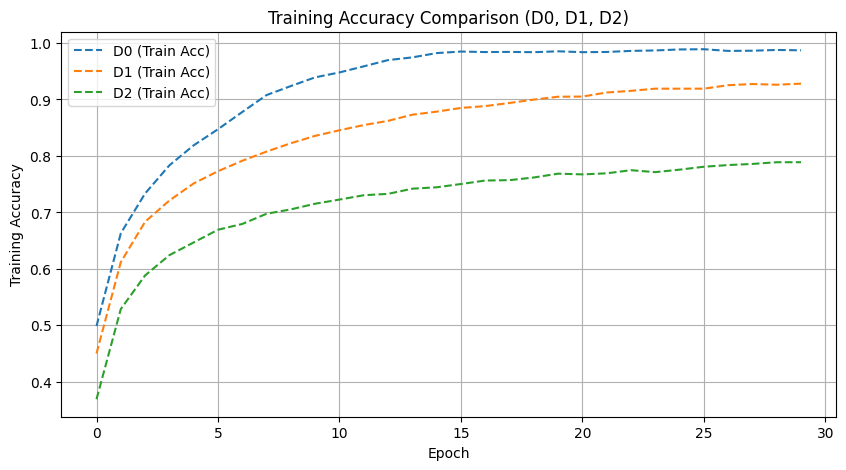

In [ ]:
plt.figure(figsize=(10, 5))
for name, h in histories_3a.items():
    plt.plot(h.history['accuracy'], label=f'{name} (Train Acc)', linestyle='--')
plt.title('Training Accuracy Comparison (D0, D1, D2)')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.legend()
plt.grid(True)
plt.show()

**Which config gives the best test accuracy?**

Model D2 (Dropout rate = 0.5) gives the best test accuracy, achieving 0.7964 (approximately 79.6%).

**Which gives the smallest overfit gap?**

Model D2 also gives the smallest overfit gap, which is -0.0029. This value is extremely close to zero, indicating that there is almost no overfitting,

##3B. Early Stopping Comparison

## Code for all 3 experiments

In [ ]:
EPOCHS_3B = 50
BATCH_SIZE_3B = 128
configs_3b = {
    'ES0': None,
    'ES2': callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    'ES3': callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
}

results_3b = []
histories_3b = {}

print("Early Stopping\n")

y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)
y_test_cat = to_categorical(y_test, 10)

for name, es_callback in configs_3b.items():
    print(f"Training Experiment {name}")
    model = build_dropout_model(0.0)
    cb_list = [es_callback] if es_callback is not None else []
    start_time = time.time()
    h = model.fit(
        x_train_C, y_train_cat,
        epochs=EPOCHS_3B,
        batch_size=BATCH_SIZE_3B,
        validation_data=(x_val_C, y_val_cat),
        callbacks=cb_list,
        verbose=0
    )
    elapsed_time = time.time() - start_time
    test_loss, test_acc = model.evaluate(x_test_C, y_test_cat, verbose=0)
    histories_3b[name] = h
    stopped_epoch = len(h.history['loss'])
    best_val_loss = min(h.history['val_loss'])
    results_3b.append({
        'Experiment': name,
        'Stopped at Epoch': stopped_epoch,
        'Best Val Loss': best_val_loss,
        'Test Acc': test_acc,
        'Time (s)': elapsed_time
    })


Early Stopping

Training Experiment ES0
Training Experiment ES2
Training Experiment ES3


Fill in the results table

In [ ]:
print(f"{'Experiment':<12} | {'Stopped at Epoch':<18} | {'Best Val Loss':<15} | {'Test Acc':<10} | {'Time (s)':<10}")
print("-" * 80)
for res in results_3b:
    print(f"{res['Experiment']:<12} | {res['Stopped at Epoch']:<18} | {res['Best Val Loss']:.4f}          | {res['Test Acc']:.4f}     | {res['Time (s)']:.1f}")

Experiment   | Stopped at Epoch   | Best Val Loss   | Test Acc   | Time (s)  
--------------------------------------------------------------------------------
ES0          | 50                 | 0.8302          | 0.7130     | 184.7
ES2          | 9                  | 0.8510          | 0.7100     | 39.9
ES3          | 13                 | 0.8569          | 0.7059     | 53.1


## Plot: val loss for ES0, ES2, ES3

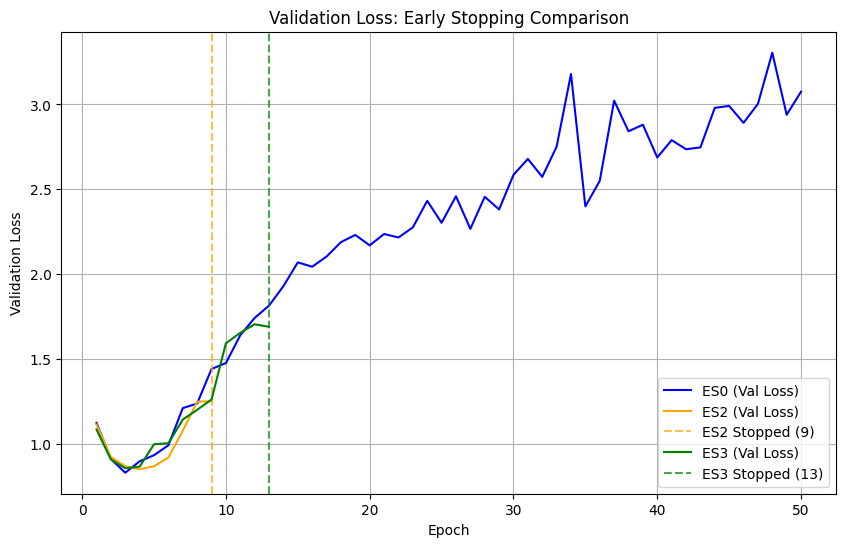

In [ ]:
plt.figure(figsize=(10, 6))
colors = {'ES0': 'blue', 'ES2': 'orange', 'ES3': 'green'}

for name, h in histories_3b.items():
    val_loss = h.history['val_loss']
    epochs_run = len(val_loss)

    plt.plot(range(1, epochs_run + 1), val_loss, label=f'{name} (Val Loss)', color=colors[name])
    if epochs_run < EPOCHS_3B:
        plt.axvline(x=epochs_run, color=colors[name], linestyle='--', alpha=0.7, label=f'{name} Stopped ({epochs_run})')

plt.title('Validation Loss: Early Stopping Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

**Is patience=5 too aggressive? Is patience=10 too lenient?**

Patience = 5 is too aggressive, because it stopped early (epoch 10), got worse val loss and lower test accuracy

Patience = 10 is not too lenient, because it trained a bit longer (epoch 14), achieved best val loss and highest test accuracy.

##Task 4: Optimizer Comparison

## 4A. Same Learning Rate — 5 Optimizers

In [ ]:
import pandas as pd

filters = configs['Medium']

optimizers = {
    'SGD': keras.optimizers.SGD(learning_rate=0.001),
    'Momentum': keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'AdaGrad': keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSProp': keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': keras.optimizers.Adam(learning_rate=0.001),
}

histories_opt = []
labels_opt = []
results_opt = []

for name, opt in optimizers.items():
    print(f"\n====================")
    print(f"Optimizer: {name}")
    print(f"====================")

    # build model
    model = build_custom_cnn(
        filters['f1'], filters['f2'],
        filters['f3'], filters['f4']
    )

    # compile
    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    h, test_acc, test_loss, elapsed_time = train_and_evaluate(
        model,
        x_train_C, y_train,
        x_val_C, y_val,
        x_test_C, y_test,
        epochs=30,
        batch_size=128
    )

    histories_opt.append(h)
    labels_opt.append(name)

    results_opt.append({
        'Optimizer': name,
        'Train Loss': h.history['loss'][-1],
        'Val Loss': h.history['val_loss'][-1],
        'Test Acc': test_acc,
        'Time (s)': elapsed_time
    })





Optimizer: SGD
Test Acc: 0.5126 | Test Loss: 1.3552 | Time: 109.2s

Optimizer: Momentum
Test Acc: 0.6595 | Test Loss: 1.3106 | Time: 111.4s

Optimizer: AdaGrad
Test Acc: 0.5713 | Test Loss: 1.2264 | Time: 111.5s

Optimizer: RMSProp
Test Acc: 0.7202 | Test Loss: 3.7963 | Time: 109.8s

Optimizer: Adam
Test Acc: 0.7099 | Test Loss: 2.6113 | Time: 115.8s


## Results Table

In [ ]:
results_df = pd.DataFrame(results_opt)
results_df

,Optimizer,Train Loss,Val Loss,Test Acc,Time (s)
0,SGD,1.322538,1.363796,0.5126,109.243258
1,Momentum,0.326218,1.277653,0.6595,111.365912
2,AdaGrad,1.116057,1.232406,0.5713,111.468266
3,RMSProp,0.032276,3.648618,0.7202,109.754357
4,Adam,0.029995,2.577059,0.7099,115.805530


## Plot of Training Loss

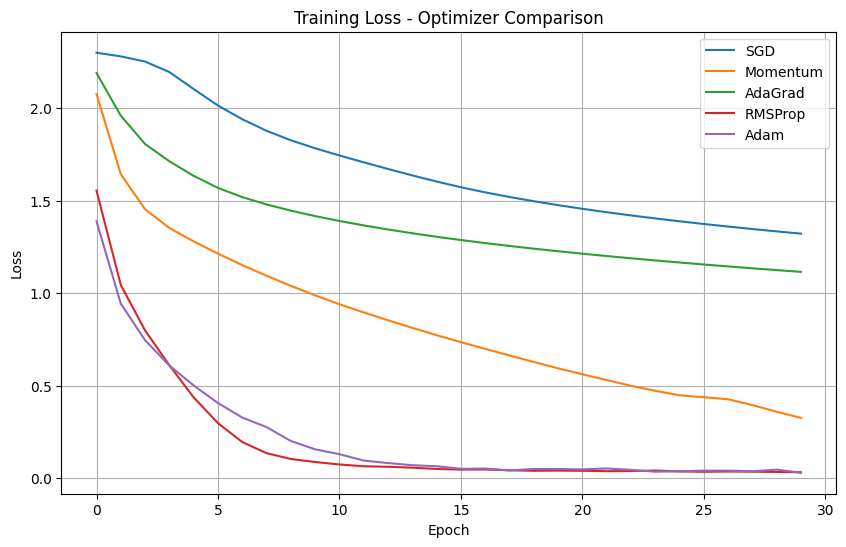

In [ ]:
plot_curves(
    histories_opt,
    labels_opt,
    metric='loss',
    title='Training Loss - Optimizer Comparison',
    ylabel='Loss'
)

## Plot of Validation Accuracy

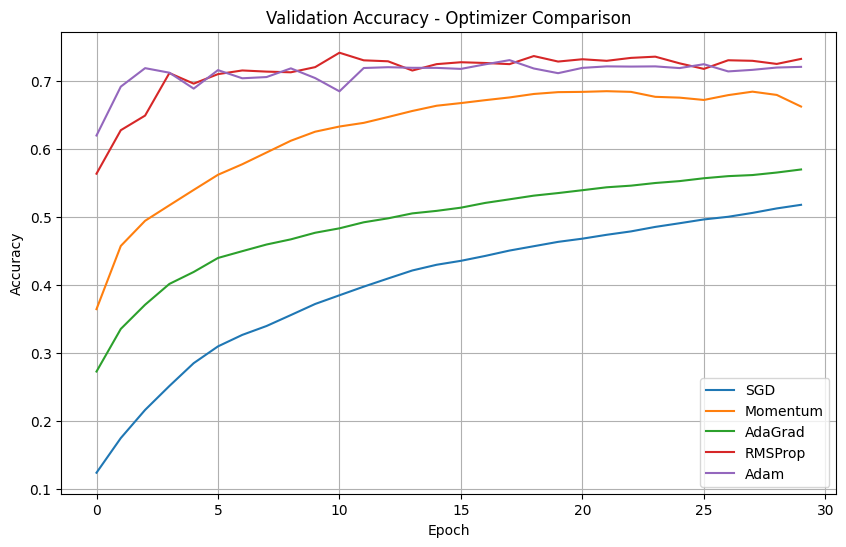

In [ ]:
plot_curves(
    histories_opt,
    labels_opt,
    metric='val_accuracy',
    title='Validation Accuracy - Optimizer Comparison',
    ylabel='Accuracy'
)

## Fastest Optimizer

In [ ]:
for name, h in zip(labels_opt, histories_opt):
    for i, acc in enumerate(h.history['val_accuracy']):
        if acc > 0.65:
            print(f"{name} reached 0.65 at epoch {i+1}")
            break

Momentum reached 0.65 at epoch 14
RMSProp reached 0.65 at epoch 4
Adam reached 0.65 at epoch 2


**Which optimizer converges fastest (reaches val_acc > 0.65 first)?**

Adam reaches the target accuracy first as it reached 0.65 at epoch 2.



## 4B. Learning Rate Sensitivity — Adam

## Learning Rates

In [ ]:
learning_rates = {
    'LR1 (0.0001)': 0.0001,
    'LR2 (0.001)': 0.001,
    'LR3 (0.01)': 0.01
}

## Training Loop

In [ ]:
filters = configs['Medium']

histories_lr = []
labels_lr = []
results_lr = []

for name, lr in learning_rates.items():
    print(f"\n===== Training with {name} =====")

    # build SAME model
    model = build_custom_cnn(
        filters['f1'], filters['f2'],
        filters['f3'], filters['f4']
    )

    # Adam with different LR
    optimizer = keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    h, test_acc, test_loss, elapsed_time = train_and_evaluate(
        model,
        x_train_C, y_train,
        x_val_C, y_val,
        x_test_C, y_test,
        epochs=30,
        batch_size=128
    )

    histories_lr.append(h)
    labels_lr.append(name)

    results_lr.append({
        'Learning Rate': lr,
        'Train Loss': h.history['loss'][-1],
        'Val Loss': h.history['val_loss'][-1],
        'Test Acc': test_acc
    })


===== Training with LR1 (0.0001) =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.6538 | Test Loss: 1.4027 | Time: 113.5s

===== Training with LR2 (0.001) =====
Test Acc: 0.7145 | Test Loss: 2.6033 | Time: 113.9s

===== Training with LR3 (0.01) =====
Test Acc: 0.1000 | Test Loss: 2.3032 | Time: 107.4s


## Results Table

In [ ]:
results_df_lr = pd.DataFrame(results_lr)
results_df_lr

,Learning Rate,Train Loss,Val Loss,Test Acc
0,0.0001,0.261102,1.414112,0.6538
1,0.0010,0.034107,2.488677,0.7145
2,0.0100,2.303370,2.303480,0.1000


## Plot Training Loss

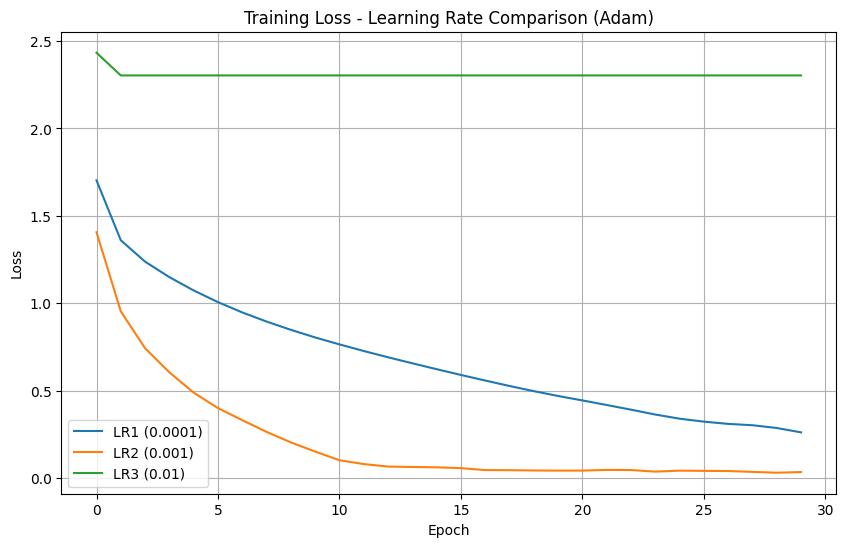

In [ ]:
plot_curves(
    histories_lr,
    labels_lr,
    metric='loss',
    title='Training Loss - Learning Rate Comparison (Adam)',
    ylabel='Loss'
)

## Plot Validation Accuracy

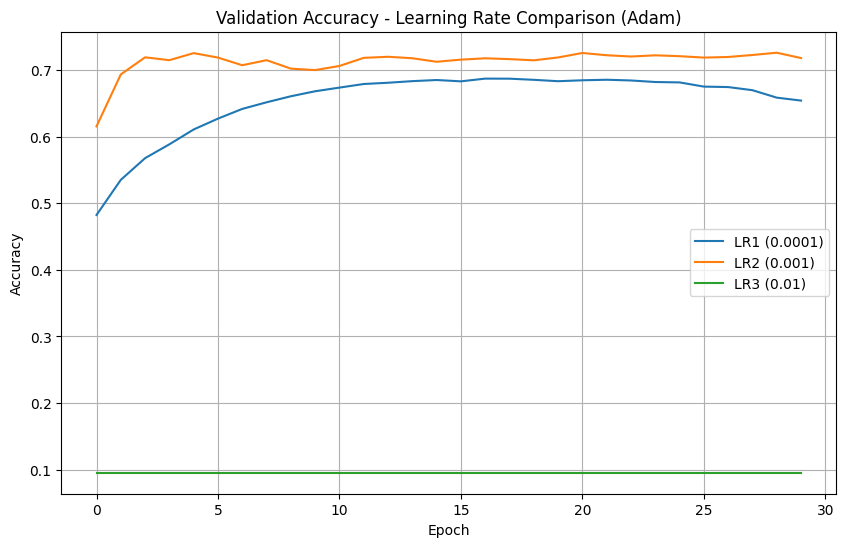

In [ ]:
plot_curves(
    histories_lr,
    labels_lr,
    metric='val_accuracy',
    title='Validation Accuracy - Learning Rate Comparison (Adam)',
    ylabel='Accuracy'
)

## Analysis Helper

In [ ]:
for name, h in zip(labels_lr, histories_lr):
    print(f"\n{name}")
    print(f"Final Val Accuracy: {h.history['val_accuracy'][-1]:.4f}")


LR1 (0.0001)
Final Val Accuracy: 0.6543

LR2 (0.001)
Final Val Accuracy: 0.7182

LR3 (0.01)
Final Val Accuracy: 0.0952


**Which learning rate is too slow? Which is unstable? Which is the best?**

Too slow: LR1 (0.0001) because learning progresses very slowly so lower final accuracy

Unstable: LR3 (0.01) since it is too large it overshoots, therefor poor accuracy

Best: LR2 (0.001) it has good balance so highest validation accuracy

## Task 5: Performance Evaluation

## 5A. Best Model Selection & Evaluation

## Building Best Model


**1. Settings Chosen & Why:**
- **Preprocessing method:** Standardization (Task 1A showed it handled variance best).

- **Architecture:** Medium (The large model achived highest accuracy, but it had high computational cost ,therefore the medium model was the best trade-off).

- **Dropout:** Dropout 0.5 (as it achieved the highest accuracy and lowest loss, indicating better generalization.).

- **Optimizer & learning rate:** Adam (LR=0.001) as it achieved the highest accuracy

- **Batch Size:** 128 as is what we used in training all the models.




In [ ]:
def build_best_model():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.5),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.5),

        # Dense
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## Data Augmentation

In [ ]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train_C)

## Early Stopping

In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

## Training Best Model (50 epochs)

In [ ]:
model = build_best_model()

start = time.time()

history_best = model.fit(
    datagen.flow(x_train_C, to_categorical(y_train, 10), batch_size=128),
    validation_data=(x_val_C, to_categorical(y_val, 10)),
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

elapsed = time.time() - start
print(f"Training Time: {elapsed:.1f}s")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 100ms/step - accuracy: 0.3514 - loss: 1.7696 - val_accuracy: 0.4961 - val_loss: 1.3890
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.4742 - loss: 1.4486 - val_accuracy: 0.5271 - val_loss: 1.3177
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.5250 - loss: 1.3272 - val_accuracy: 0.6134 - val_loss: 1.0928
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 80ms/step - accuracy: 0.5602 - loss: 1.2293 - val_accuracy: 0.6360 - val_loss: 1.0271
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 80ms/step - accuracy: 0.5816 - loss: 1.1710 - val_accuracy: 0.6491 - val_loss: 0.9968
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.6010 - loss: 1.1192 - val_accuracy: 0.6620 - val_loss: 0.9647
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.6136 - loss: 1.0915 - val_accuracy: 0.6553 - val_loss: 0.9985
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.6247 - loss: 1.0616 -

## Final Test Accuracy

In [ ]:
test_loss, test_acc = model.evaluate(x_test_C, to_categorical(y_test, 10), verbose=0)
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Accuracy: 0.7116


## Confusion Matrix + Report

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


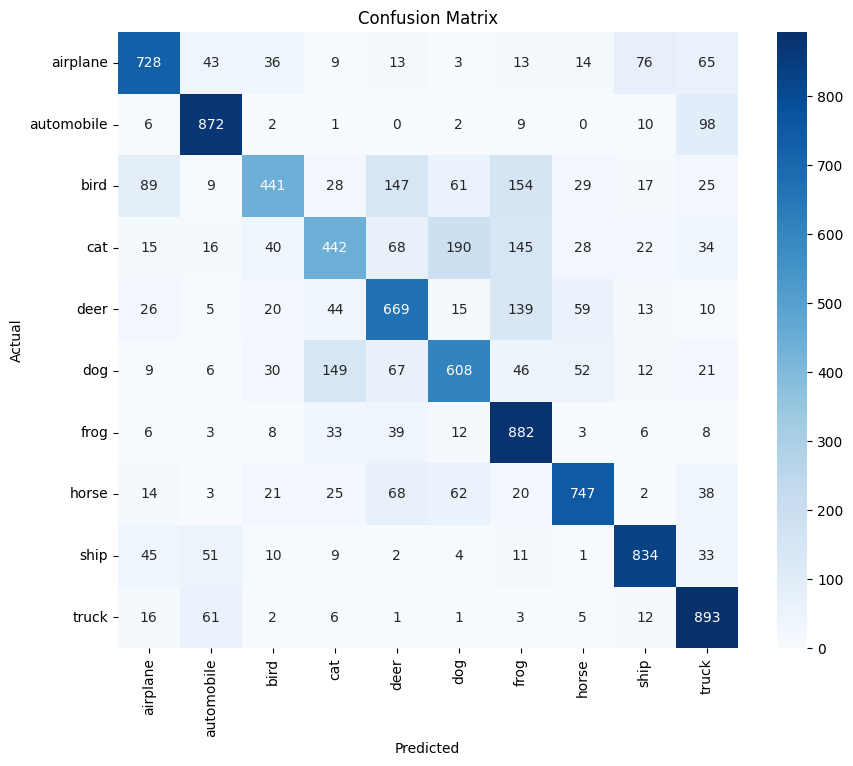

              precision    recall  f1-score   support

    airplane       0.76      0.73      0.75      1000
  automobile       0.82      0.87      0.84      1000
        bird       0.72      0.44      0.55      1000
         cat       0.59      0.44      0.51      1000
        deer       0.62      0.67      0.65      1000
         dog       0.63      0.61      0.62      1000
        frog       0.62      0.88      0.73      1000
       horse       0.80      0.75      0.77      1000
        ship       0.83      0.83      0.83      1000
       truck       0.73      0.89      0.80      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.70     10000
weighted avg       0.71      0.71      0.70     10000



In [ ]:
y_pred = np.argmax(model.predict(x_test_C), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

## Misclassified Samples

In [ ]:
y_pred = np.argmax(model.predict(x_test_C, verbose=0), axis=1)
y_true = y_test.flatten()

misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_true)}")

Total misclassified: 2884 / 10000


## Show Misclassified Images

In [ ]:
def show_misclassified(true_class, n=5):
    idx = [i for i in misclassified_idx if y_test[i] == true_class][:n]

    fig, axes = plt.subplots(1, n, figsize=(15, 3))

    for ax, i in zip(axes, idx):
        ax.imshow(x_test[i].astype('uint8'))
        ax.set_title(f"True: {CLASS_NAMES[y_test[i][0]]}\nPred: {CLASS_NAMES[y_pred[i]]}")
        ax.axis('off')

    plt.show()

## Worst 3 Classes (Lowest Recall)

In [ ]:
report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)

recalls = [(cls, report[cls]['recall']) for cls in CLASS_NAMES]
recalls_sorted = sorted(recalls, key=lambda x: x[1])

worst_classes = [CLASS_NAMES.index(cls[0]) for cls in recalls_sorted[:3]]

print("Worst classes:", [CLASS_NAMES[i] for i in worst_classes])

Worst classes: ['bird', 'cat', 'dog']


## Show Worst Classes Errors

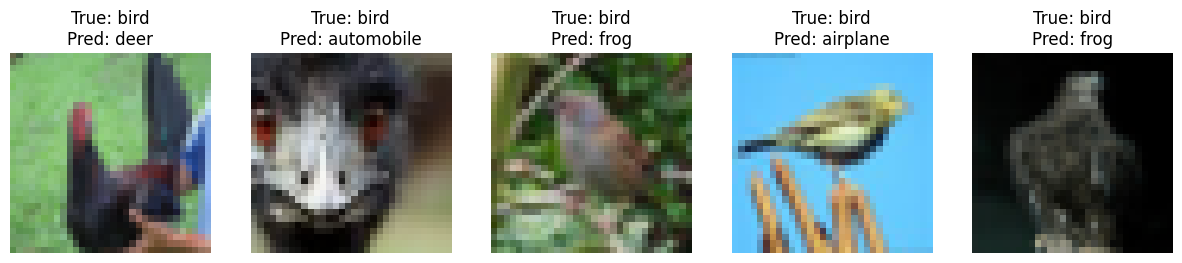

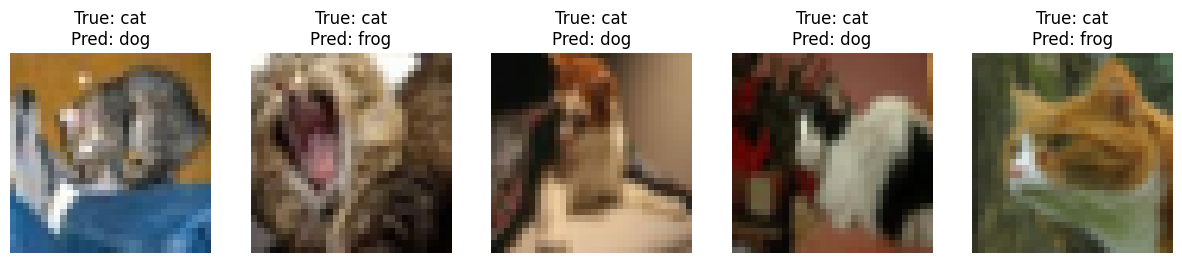

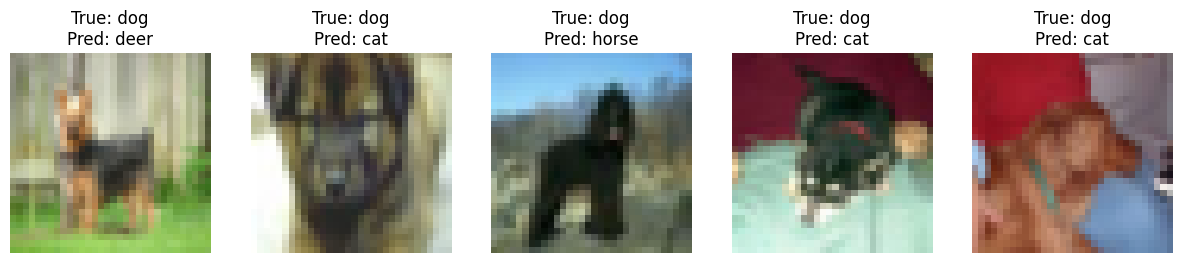

In [ ]:
for cls in worst_classes:
    show_misclassified(cls, 5)

## Most Confused Pairs

In [ ]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

pairs = []
for i in range(10):
    for j in range(10):
        if i != j:
            pairs.append(((i, j), cm_no_diag[i][j]))

pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)
top_pairs = pairs_sorted[:3]

for (i, j), val in top_pairs:
    print(f"{CLASS_NAMES[i]} → {CLASS_NAMES[j]}: {val}")

cat → dog: 190
bird → frog: 154
dog → cat: 149


## Show Confusion Examples

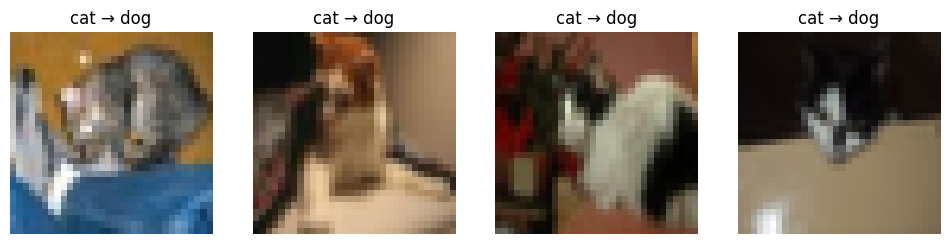

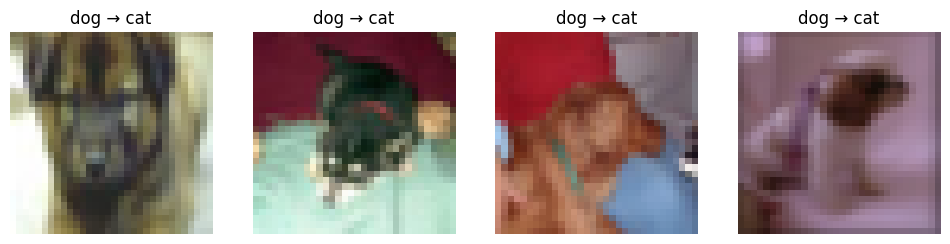

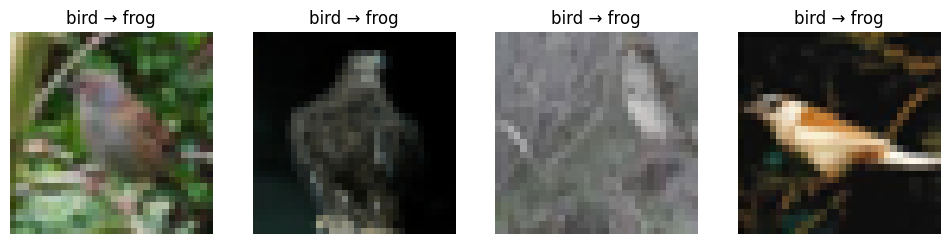

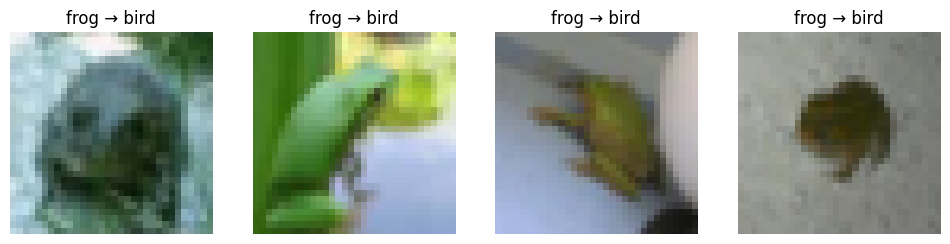

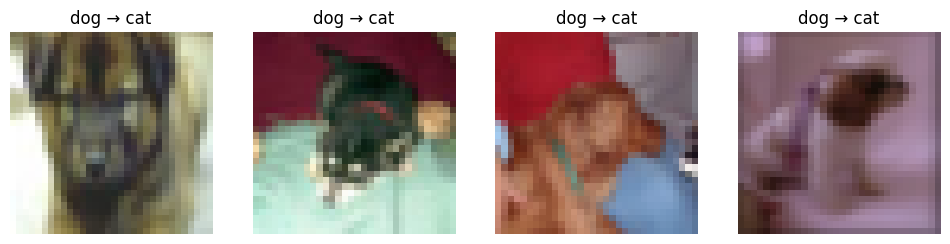

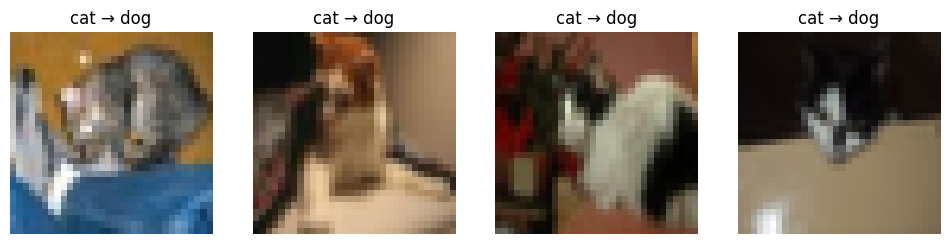

In [ ]:
def show_confusion_pair(i, j, n=4):
    idx = [k for k in range(len(y_test)) if y_test[k] == i and y_pred[k] == j][:n]

    fig, axes = plt.subplots(1, n, figsize=(12, 3))

    for ax, k in zip(axes, idx):
        ax.imshow(x_test[k].astype('uint8'))
        ax.set_title(f"{CLASS_NAMES[i]} → {CLASS_NAMES[j]}")
        ax.axis('off')

    plt.show()

for (i, j), _ in top_pairs:
    show_confusion_pair(i, j)
    show_confusion_pair(j, i)


**Dog vs Cat** **:** both have similar body shapes, ears, and textures at low resolution.

**Cat vs Frog :** frogs may appear as simple green blobs; cats in certain poses can look similar in shape.

**Bird vs Frog :** both can appear as small rounded shapes with unclear limbs at low resolution.

The main issue is low resolution (32×32) which removes fine details.


## TASK 6 — TRANSFER LEARNING

## Resize Data for VGG16 (48×48)

In [ ]:
x_train_resized = tf.image.resize(x_train_C, (48, 48)).numpy()
x_val_resized   = tf.image.resize(x_val_C, (48, 48)).numpy()
x_test_resized  = tf.image.resize(x_test_C, (48, 48)).numpy()

y_train_cat = to_categorical(y_train, 10)
y_val_cat   = to_categorical(y_val, 10)
y_test_cat  = to_categorical(y_test, 10)

# Training Function

In [ ]:
def train_model(model, x_tr, y_tr, x_val, y_val, x_test, y_test,
                epochs=20, batch_size=128):

    start = time.time()

    history = model.fit(
        x_tr, y_tr,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    elapsed = time.time() - start
    print(f"Test Accuracy: {test_acc:.4f} | Time: {elapsed:.1f}s")

    return history, test_acc, elapsed

In [ ]:
def get_params(model):
    trainable = np.sum([np.prod(v.shape) for v in model.trainable_weights])
    non_trainable = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])
    return trainable, non_trainable

## MODEL 1 — FROM SCRATCH

In [ ]:
def build_medium_48():
    model = models.Sequential([
        layers.Conv2D(32, 3, activation='relu', padding='same',
                      input_shape=(48, 48, 3)),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
model1 = build_medium_48()

tp1, ntp1 = get_params(model1)

h1, acc1, t1 = train_model(
    model1,
    x_train_resized, y_train_cat,
    x_val_resized, y_val_cat,
    x_test_resized, y_test_cat
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.4932 - loss: 1.4203 - val_accuracy: 0.6052 - val_loss: 1.1302
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.6641 - loss: 0.9640 - val_accuracy: 0.6665 - val_loss: 0.9455
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7443 - loss: 0.7353 - val_accuracy: 0.6766 - val_loss: 0.9527
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8115 - loss: 0.5536 - val_accuracy: 0.6703 - val_loss: 1.0687
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8474 - loss: 0.4375 - val_accuracy: 0.6758 - val_loss: 1.1204
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8755 - loss: 0.3521 - val_accuracy: 0.6619 - val_loss: 1.3649
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9166 - loss: 0.2362 - val_accuracy: 0.6550 - val_loss: 1.5800
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9406 - loss: 0.1686 - val_a

# MODEL 2 — FEATURE EXTRACTION (VGG16 FROZEN)

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
base = VGG16(weights='imagenet', include_top=False,
             input_shape=(48, 48, 3))
base.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model2 = models.Sequential([
    base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model2.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
tp2, ntp2 = get_params(model2)
model2.summary()


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_28 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
h2, acc2, t2 = train_model(
    model2,
    x_train_resized, y_train_cat,
    x_val_resized, y_val_cat,
    x_test_resized, y_test_cat
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 81ms/step - accuracy: 0.5332 - loss: 1.3392 - val_accuracy: 0.6464 - val_loss: 1.0284
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.6357 - loss: 1.0574 - val_accuracy: 0.6690 - val_loss: 0.9639
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.6584 - loss: 0.9845 - val_accuracy: 0.6800 - val_loss: 0.9348
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.6754 - loss: 0.9402 - val_accuracy: 0.6843 - val_loss: 0.9143
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.6871 - loss: 0.9050 - val_accuracy: 0.6906 - val_loss: 0.9034
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.6975 - loss: 0.8696 - val_accuracy: 0.6900 - val_loss: 0.8918
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.7055 - loss: 0.8440 - val_accuracy: 0.6928 - val_loss: 0.8899
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.7100 - loss: 0.8258 - 

## MODEL 3 — FINE TUNING (LR = 1e-5)

In [ ]:
base3 = VGG16(weights='imagenet', include_top=False,
              input_shape=(48, 48, 3))

for layer in base3.layers[:-4]:
    layer.trainable = False
for layer in base3.layers[-4:]:
    layer.trainable = True

In [ ]:
model3 = models.Sequential([
    base3,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model3.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
tp3, ntp3 = get_params(model3)
model3.summary()


Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_29 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
h3, acc3, t3 = train_model(
    model3,
    x_train_resized, y_train_cat,
    x_val_resized, y_val_cat,
    x_test_resized, y_test_cat
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 90ms/step - accuracy: 0.4302 - loss: 1.6294 - val_accuracy: 0.6843 - val_loss: 0.9484
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.6608 - loss: 1.0038 - val_accuracy: 0.7373 - val_loss: 0.7692
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.7189 - loss: 0.8344 - val_accuracy: 0.7598 - val_loss: 0.6998
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.7521 - loss: 0.7397 - val_accuracy: 0.7762 - val_loss: 0.6469
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.7748 - loss: 0.6678 - val_accuracy: 0.7879 - val_loss: 0.6162
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.7925 - loss: 0.6163 - val_accuracy: 0.7968 - val_loss: 0.5936
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.8082 - loss: 0.5661 - val_accuracy: 0.8044 - val_loss: 0.5735
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.8223 - loss: 0.5290 - 

## MODEL 4 — FINE TUNING (LR = 1e-3)

In [ ]:
base4 = VGG16(weights='imagenet', include_top=False,
              input_shape=(48, 48, 3))

for layer in base4.layers[:-4]:
    layer.trainable = False
for layer in base4.layers[-4:]:
    layer.trainable = True

In [ ]:
model4 = models.Sequential([
    base4,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model4.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
tp4, ntp4 = get_params(model4)
model4.summary()


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_30 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
h4, acc4, t4 = train_model(
    model4,
    x_train_resized, y_train_cat,
    x_val_resized, y_val_cat,
    x_test_resized, y_test_cat
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 82ms/step - accuracy: 0.1000 - loss: 2.3089 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.0991 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.0993 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.1007 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.0990 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.0985 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.0990 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - accuracy: 0.0998 - loss: 2.3027 - 

## RESULTS TABLE

In [ ]:
import pandas as pd

results = pd.DataFrame(
    [
        ["From Scratch", tp1, ntp1, acc1, t1],
        ["Feature Extraction", tp2, ntp2, acc2, t2],
        ["Fine-Tune (lr=1e-5)", tp3, ntp3, acc3, t3],
        ["Fine-Tune (lr=1e-3)", tp4, ntp4, acc4, t4],
    ],
    columns=[
        "Model",
        "Trainable Params",
        "Non-Trainable Params",
        "Test Acc",
        "Time (s)"
    ]
)
results

,Model,Trainable Params,Non-Trainable Params,Test Acc,Time (s)
0,From Scratch,2427690,0.0,0.6716,161.623588
1,Feature Extraction,133898,14714688.0,0.6934,414.804039
2,Fine-Tune (lr=1e-5),7213322,7635264.0,0.8219,478.165817
3,Fine-Tune (lr=1e-3),7213322,7635264.0,0.1000,463.532439


## PLOTS

Accuracy

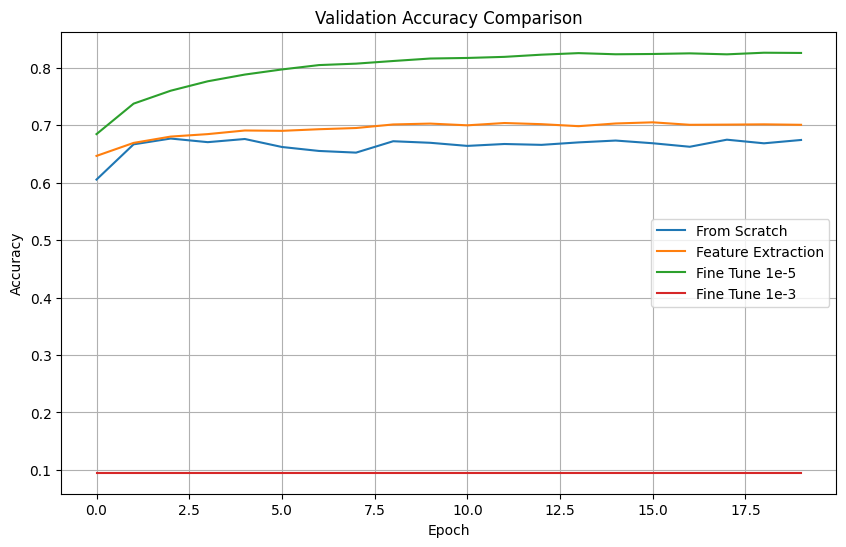

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(h1.history['val_accuracy'], label="From Scratch")
plt.plot(h2.history['val_accuracy'], label="Feature Extraction")
plt.plot(h3.history['val_accuracy'], label="Fine Tune 1e-5")
plt.plot(h4.history['val_accuracy'], label="Fine Tune 1e-3")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

Loss

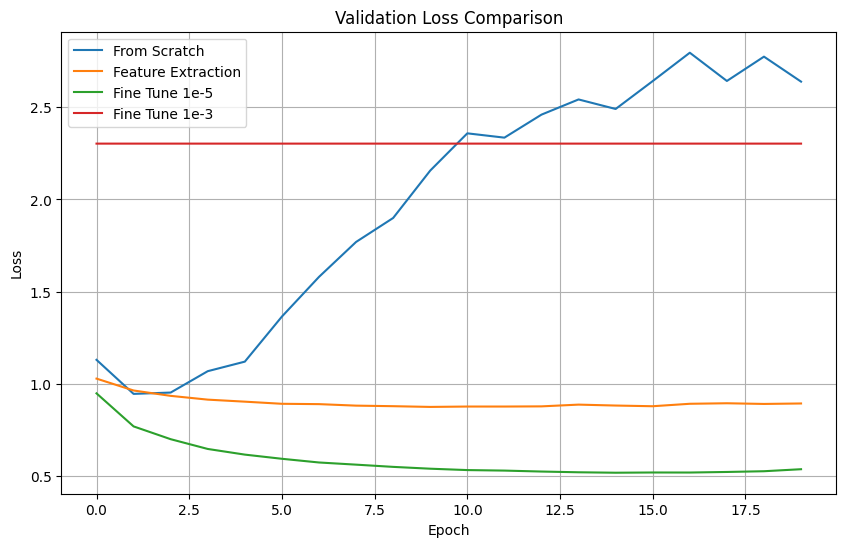

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(h1.history['val_loss'], label="From Scratch")
plt.plot(h2.history['val_loss'], label="Feature Extraction")
plt.plot(h3.history['val_loss'], label="Fine Tune 1e-5")
plt.plot(h4.history['val_loss'], label="Fine Tune 1e-3")

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

### 48. Why does Model 4 (lr=0.001) perform differently from Model 3 (lr=1e-5)?
Because learning rate = 0.001 is too high for fine-tuning pretrained VGG16 layers, it destroys learned ImageNet features.

---

### 49. Does transfer learning outperform training from scratch on CIFAR-10? Why or why not?
Yes, VGG16 significantly improves performance over training from scratch because it uses pretrained visual features.

**Team Members Contribution**


---


---





**Member name:** Ahmed Tarek El-kasaby (ID: 20230023)

**Tasks Completed:**  

*   Task 1A,1B
*   Task 2A,2C
* Task 3A,3B



**Specific Contributions:**


*   Implemented all 3 normalization methods with their graphs and results table.
*   Trained the baseline cnn with and without augmentation, and compared them using graph and by reporting the gap.
* Tested 3 filters and compared between them using model.summary() & plotted them on one graph.
* Tested 3 depth,and compared them and deduced that not always the deepest model performs best.
* Tested 3 dropout rates & compared between them using graphs & reporting the overfit gap.
*   Used the model with no dropout to test different early stopping configurations, and plotted their validation loss graphs.



**Time Spent:**
 10 hours


---


---


**Member name:** Sana Sherif Mohammed(ID:20230180)

**Tasks Completed:**



* Task 4A,4B
*   Task 5A,5B
* Task 6A

**Specific Contributions:**



*   Trained the best model and stated why these settings where chosen,reported the final test accuracy, and plotted the confusion matrix.
* Trained the model with 5 optimizers, compared using graphs and losses.
* Tested 3 learning rates, and mentioned which is too slow,which is unstable,and which is the best.
* Found the 3 worst-performing classes, displayed images with their true label and predicted label, found the top 3 most confused pairs, and wrote why these classes are hard to distinguish.
* Resized CIFAR-10 to fit VGG16, built the from scratch model, the feature extraction model(frozen VGG16), the fine tuning model (partial unfreeze), and fine tuning (higher learning rate). Plotted the curves,and stated why model 4 perform differently from model 3. Answered does transfer learning outperform training from scratch or not.



**Time Spent:**
12 hours